# Dictionary Learning w/t MOD

In this notebook we show how to do dictionary learning using the "modified MOD algorithm" presented [here](https://arxiv.org/abs/2511.14147). Let $D$ be the dictionary we would like to recover. First, we use `mod_sample!` to collect several rough approximations to $D$. Then, we use k-medioids clustering to "average" these sample recoveries.

First, some miscellanious setup.

In [1]:
using Pkg
Pkg.activate(".")

using LinearAlgebra, StaticArrays, Random, SparseArrays
using StatsBase
using Base.Threads
using CUDA, Adapt, KernelAbstractions, GPUArrays
using Plots, StatsPlots, JLD2
using Clustering, Graphs
using DictionaryLearning
using FFTW

include("../debug.jl")

# plot theme
theme(:rose_pine)

# choose backend
back = CUDA.functional() ? CUDABackend() : CPU()
# back = CPU()

# set threads
BLAS.set_num_threads(nthreads())

println("$INF backend: $back")
println("$INF # threads: $(nthreads())")
;

  Activating project at `~/DictionaryLearning/examples/dictionary-learning`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[INF] backend: CUDABackend(false, false)
[INF] # threads: 32


Now choose the dictionary that will be learned. Here we use the Green's matrix of the Foldy-Lax model. See the relevant example for how this is generated. Later, the dictionary is assumed to have normalized columns.

In [2]:
@load "../../temp/fl-example/fls.jld2" fls
D = fls.G
# D = randn(10, 20)

# normalize columns
D ./= sqrt.(sum(abs2, D, dims=1))

;

Specify how the dictionary should be sampled and how many approximate recoveries should be performed.

In [3]:
# how many random observations
n = 10000

# sparsity of those observations
s = 6 

# how many approximate recoveries
nsamples = 1

;

Move everything to the appropriate backend and compute the observations.

In [4]:
# move to backend
D = adapt(back, D)
m, k = size(D)

println("$INF m = $m")
println("$INF k = $k")

# generate observations
X = adapt(back, gen_sparse_samples(eltype(D), k, n, s))
Y = D*X
;

[INF] m = 775
[INF] k = 361


Before collecting samples, we need to specify settings for collecting the sample recoveries. The sparsity regularization parameter and step size can be finicky and probably needs to be tuned for different dictionaries. If the error does not converge, try decreasing the step size or changing the regularization so that the resulting sparsity is closer to $s$. If you get an error about being row-rank defficient, you probably need to provide more observations or lower the regularization. Why this algorithm works, and the relationship between the sparsity, error, step size, and regularization parameter is not well understood.

In [ ]:
mss = MODSampleStruct(
    Y, k, 
    2.5,            # sparsity regularization parameter
    eps=1e-2,       # termination error threshold
    dt=0.1,        # step size
    max_iters=1000,     # maximum allowed iterations
    sparse_ls_cutoff=0.05
)
;

Now, actually collect the approximate dictionaries.

In [9]:
let
    msws = MODSampleWorkStruct(mss)

    for i in 1:nsamples
        println("$INF sample $i/$nsamples")
        try
            mod_sample!(mss, msws)

            B = copy(mss.Ds[end])
            align_dict!(D, B)

            println("$TAB$INF dictionary recovery error: $(norm(D - B)/norm(D))")
        catch err
            if isa(err, SingularException)
                @warn "Sample $i became rank-defficient"
            else
                rethrow()
            end
        end
    end
end

[INF] sample 1/1
     [INF] dictionary recovery error: 0.1457229609458713


[INF] mean L1 errors of final iterations:  0.10179980114166672
[INF] % mean sparsities of final iterations: 0.8013161290322581%


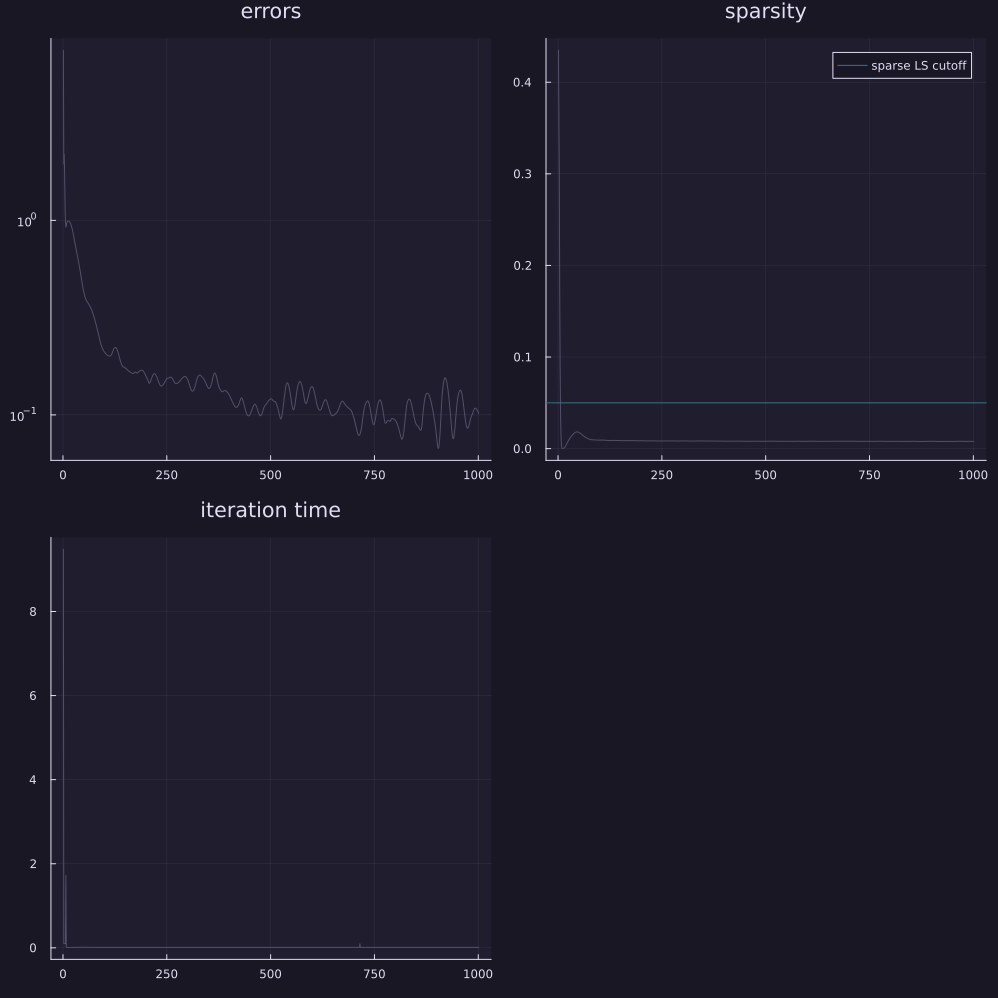

In [15]:
println("$INF mean L1 errors of final iterations:  $(mean(last.(mss.err_hist)))")
println("$INF % mean sparsities of final iterations: $(100*mean(last.(mss.sparsity_hist)))%")

p1 = plot(mss.err_hist, yscale=:log10, label=:none, title="errors")
p2 = plot(mss.sparsity_hist, label=:none, title="sparsity")
hline!([mss.sparse_ls_cutoff], label="sparse LS cutoff")
p3 = plot(mss.elap_hist, label=:none, title="iteration time")

plot(p1, p2, p3, layout=(2, 2), size=(1000, 1000))

In [ ]:
abstract type AbstractMODIterControlStruct{T} end

struct MODIterNoControlStruct{T} <: AbstractMODIterControlStruct{T}
end

function mod_iter_control!(
    ms::MODSampleStruct{T1, T2}, mws::MODSampleWorkStruct{T1},
    mic::MODIterNoControlStruct{T1}
)
end


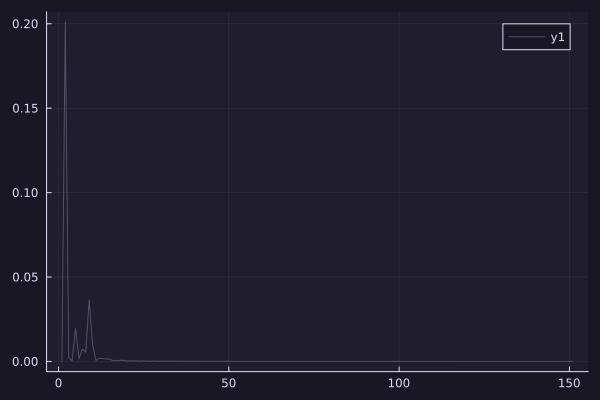

In [ ]:
function r2rfft(v::Vector{T}) where T <: Union{Float32, Float64}
    v .-= mean(v)
    n = length(v)
    fft = FFTW.r2r(v, FFTW.R2HC)
    vc = Vector{Complex{T}}(undef, div((n - 1), 2)+1)

    vc[1] = fft[1]
    for i in 2:div((n - 1),2)+1
        vc[i] = fft[i]*1im + fft[n - i]
    end
    vc ./= norm(v) * sqrt(n)
    return vc
end

let
    v = sqrt.(mss.errhist[end].^2 .+ mss.sprshist[end].^2)
    frame_size = 100
    i = length(v)
    frame = v[i-frame_size:i]
    plot(abs2.(r2rfft(frame)))
end

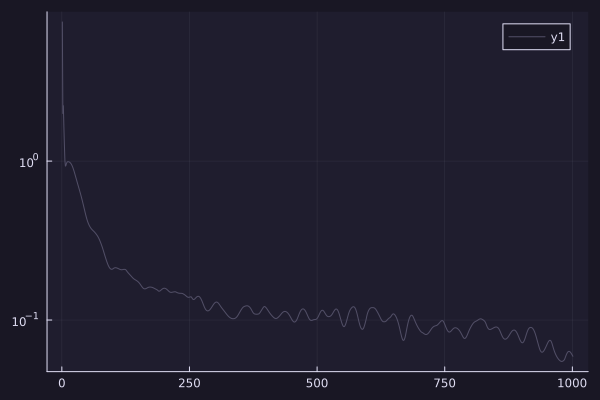

In [113]:
let
    v = sqrt.(mss.errhist[end].^2 .+ mss.sprshist[end].^2)
    plot(v, yscale=:log10)
end

Cluster columns of the apprimxate recoveries to get a more accurate dictionary. Then align the resulting dictionary with the truth and measure how accurate the reconstruction is.

In [ ]:
# allocate space for recoverd dictionary
Dr = similar(D)

# do clustering
mod_cluster!(Dr, mss)

# align to true dictionary
align_dict!(D, Dr)

# measure reconstruction
println("$INF recovery error: $(norm(D - Dr)/norm(D))")

[INF] recovery error: 0.09258636769515834


Visualize the covariance between the true dictionary and the recovered one.

In [111]:
# heatmap(adapt(CPU(), abs.(D' * Dr)), yflip=true, title="covariance")